# Single-molecule CTCF analysis on real DiMeLo-seq data

This tutorial walks through the **single-molecule** and **reference-comparison** capabilities of
`dimelo` on a full-depth one-pot DiMeLo-seq CTCF experiment, answering questions the ensemble
pileup cannot:

| Section | Question | API |
|---|---|---|
| **A** | Which individual reads carry *real* signal vs a negative control? (Q3) | `dimelo.background.call_true_signal_reads` |
| **B** | How strongly is each site bound? (Q6) | `dimelo.background.binding_strength` |
| **C** | Is there a protected **footprint** at the bound motif? (Q5) | `dimelo.footprint` |
| **D** | Does the sequence under our sites match the annotated CTCF motif? (Q8) | `dimelo.jaspar` + `dimelo.motifs` |
| **E** | What public feature is each read-cluster associated with? (Q8) | `dimelo.cluster_reference` + `dimelo.encode` |

**Dataset.** One-pot DiMeLo-seq targeting CTCF with 6mA (`A,0`), aligned to **T2T-CHM13v2.0**:
- `barcode17` — CTCF-targeted (pA-Hia5 tethered to anti-CTCF)
- `barcode18` — free-pA / untargeted **negative control**

The reads were pre-extracted to per-read basemod HDF5s over ~19k CTCF-region windows
(`modkit extract` → `reads.combined_basemods.h5`), so we load windows directly rather than
re-processing the 200 GB BAMs.

> **Data location.** This runs on lab data under `/oak/stanford/groups/altemose/...`. The repo
> ships a small `dimelo/test/data/*.ctcf_demo*` subset that mirrors the same structure at lower
> depth; the executed numbers below are from the full-depth data.

In [1]:
%matplotlib inline
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dimelo import (
    cluster, background, footprint, jaspar, motifs, cluster_reference, encode,
    plotting, plotting_matplotlib,
)

warnings.filterwarnings("ignore")

OAK = Path("/oak/stanford/groups/altemose/data/20250110_NG_one_pot")
PKG = OAK / "dimelo_package"
REF = "/oak/stanford/groups/altemose/references/fastas/chm13v2.0.fasta"
OUT = Path("artifacts/tutorial_ctcf"); OUT.mkdir(parents=True, exist_ok=True)

H5 = {
    "barcode17": str(PKG / "allctcf_extract_1_1/reads.combined_basemods.h5"),  # CTCF-targeted
    "barcode18": str(PKG / "allctcf_extract_2_1/reads.combined_basemods.h5"),  # control
}
REGIONS = str(PKG / "allctcf_extract_1_1/regions.processed.bed")  # the extracted CTCF windows
print("h5 files present:", {k: Path(v).exists() for k, v in H5.items()})

h5 files present: {'barcode17': True, 'barcode18': True}


## Load per-read windows

`cluster.extract_read_windows` reads the per-read basemod HDF5 and returns, for every read, a
window centered on each region: a **data matrix** (1 = methylated call, 0 = unmethylated) and a
**val matrix** (1 = the base was assessed, 0 = not covered / not an A). We use two anchorings:

- **Broad peak windows** (this cell) — centered on the extracted CTCF regions, ±150 bp. Maximizes
  reads per site, which is what **occupancy / binding-strength** (Sections A–B) need for statistical
  power.
- **Motif-centered windows** (Section C) — centered exactly on the JASPAR motif match, needed for
  base-precise **footprint** resolution.

In [2]:
# broad peak windows over the first 2,500 extracted CTCF regions (fast + deep)
region_subset = OUT / "regions_subset.bed"
pd.read_csv(REGIONS, sep="\t", header=None).head(2500).to_csv(
    region_subset, sep="\t", header=False, index=False
)

WIN_BROAD = 150   # half-window -> 300 columns
res_broad = {
    sid: cluster.extract_read_windows(h5, motifs=["A,0"], regions=[str(region_subset)],
                                      window_size=WIN_BROAD)
    for sid, h5 in H5.items()
}
for sid, r in res_broad.items():
    print(f"{sid}: {r.data_matrix.shape[0]:,} read-windows x {r.data_matrix.shape[1]} bp")

barcode17: 68,189 read-windows x 300 bp
barcode18: 24,016 read-windows x 300 bp


### Per-read occupancy evidence

For each read we count, in a ±75 bp window around the region center, the number of **methylated**
A calls (`modified_count`, k) out of **assessed** A positions (`valid_count`, n). This `(k, n)` per
read — for both the targeted and control conditions — is the input to the control-calibrated
calling below.

In [3]:
OCC_HALF = 75

def read_evidence(r, sample_id, condition, half=OCC_HALF):
    data, val = r.data_matrix, r.val_matrix
    md = pd.DataFrame(r.metadata).reset_index(drop=True)
    c = data.shape[1] // 2
    sd, sv = data[:, c - half:c + half], val[:, c - half:c + half]
    assessed = sv > 0
    n = assessed.sum(axis=1)
    k = ((sd >= 0.5) & assessed).sum(axis=1)
    region_id = (md["chromosome"].astype(str) + ":" +
                 md["region_start"].astype(str) + "-" + md["region_end"].astype(str))
    out = pd.DataFrame({
        "region_id": region_id.to_numpy(),
        "sample_id": sample_id,
        "condition": condition,
        "read_id": md["read_name"].astype(str).to_numpy() + "@" + region_id.to_numpy(),
        "modified_count": k.astype(int),
        "valid_count": n.astype(int),
    })
    return out[out["valid_count"] > 0].reset_index(drop=True)

evidence = pd.concat([
    read_evidence(res_broad["barcode17"], "barcode17", "targeted"),
    read_evidence(res_broad["barcode18"], "barcode18", "control"),
], ignore_index=True)

print("evidence rows:", len(evidence))
print(evidence.groupby("condition").agg(reads=("read_id", "size"),
                                         mean_frac=("modified_count", lambda s: (s / 20).mean())))
evidence.head()

evidence rows: 91648
           reads  mean_frac
condition                  
control    23870   0.056047
targeted   67778   0.127995


,region_id,sample_id,condition,read_id,modified_count,valid_count
0,chr17:137882-141882,barcode17,targeted,982317ca-58eb-499d-8e98-c549952df307@chr17:137...,3,19
1,chr17:137882-141882,barcode17,targeted,a92abf1e-4dc9-488b-9039-37762a23346b@chr17:137...,2,16
2,chr17:137882-141882,barcode17,targeted,eb044e00-a128-4dd0-bc95-a58fc9e956bb@chr17:137...,1,32
3,chr17:137882-141882,barcode17,targeted,2fb18756-8966-4181-b101-26d599c28615@chr17:137...,2,13
4,chr17:137882-141882,barcode17,targeted,3417309c-aedd-4ff4-b261-3648e734ede0@chr17:137...,1,11


## Section A — control-calibrated true-signal calling (Q3)

`background.call_true_signal_reads` fits a **beta-binomial null** to the control reads' `(k, n)` at
each site (with a pooled fallback where control coverage is thin), then computes an upper-tail
p-value for every *target* read, applies Benjamini-Hochberg across reads, and flags
`is_true_signal` at the chosen FDR. It also returns a soft `occupancy_posterior` (a 2-component
mixture posterior that a read carries real signal).

`summarize_site_occupancy` then gives a **Bayesian Beta-Binomial** per-site occupancy with a
credible interval.

In [4]:
called = background.call_true_signal_reads(
    evidence=evidence,
    target_conditions=["targeted"],
    control_conditions=["control"],
    fdr=0.05,
    min_control_reads=5,
)
n_true = int(called["is_true_signal"].sum())
print(f"target reads called true-signal: {n_true:,} / {len(called):,} "
      f"({100 * n_true / len(called):.1f}%)")

site_occupancy = background.summarize_site_occupancy(called)
print("sites summarized:", len(site_occupancy))
called[["read_id", "region_id", "read_mod_fraction", "background_rate",
        "q_value", "is_true_signal", "occupancy_posterior"]].head()

target reads called true-signal: 7,685 / 67,778 (11.3%)
sites summarized: 1792


,read_id,region_id,read_mod_fraction,background_rate,q_value,is_true_signal,occupancy_posterior
0,982317ca-58eb-499d-8e98-c549952df307@chr17:137...,chr17:137882-141882,0.157895,0.019179,0.234017,False,0.800022
1,a92abf1e-4dc9-488b-9039-37762a23346b@chr17:137...,chr17:137882-141882,0.125000,0.019179,0.294363,False,0.776210
2,eb044e00-a128-4dd0-bc95-a58fc9e956bb@chr17:137...,chr17:137882-141882,0.031250,0.019179,0.516694,False,0.640845
3,2fb18756-8966-4181-b101-26d599c28615@chr17:137...,chr17:137882-141882,0.153846,0.019179,0.261800,False,0.789313
4,3417309c-aedd-4ff4-b261-3648e734ede0@chr17:137...,chr17:137882-141882,0.090909,0.019179,0.392255,False,0.732668


### Single-molecule reads at the most-occupied site
Each row is one read, colored by its posterior probability of carrying real CTCF signal.

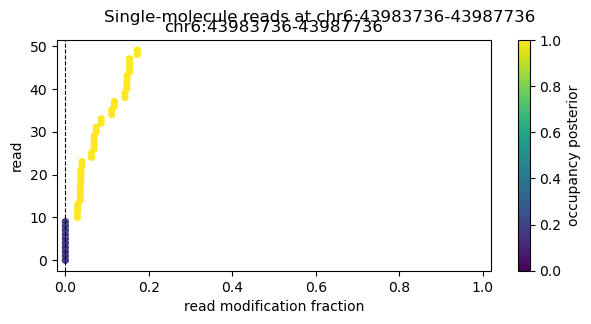

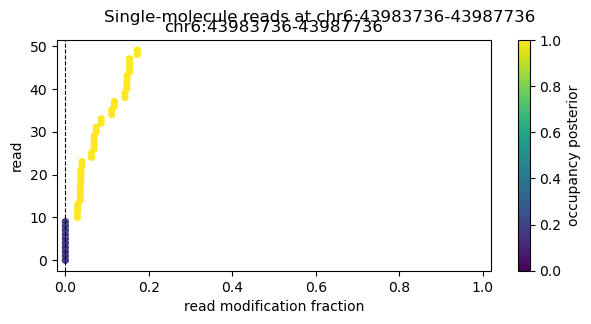

In [5]:
top_site = site_occupancy.sort_values("occupancy_rate", ascending=False).iloc[0]["region_id"]
raster = plotting.prepare_true_signal_read_data(
    called_reads=called, region_id=top_site, color_by="occupancy_posterior"
)
fig, _ = plotting_matplotlib.plot_true_signal_read_raster_matplotlib(
    raster, title=f"Single-molecule reads at {top_site}"
)
fig

### Occupancy-rate track across sites

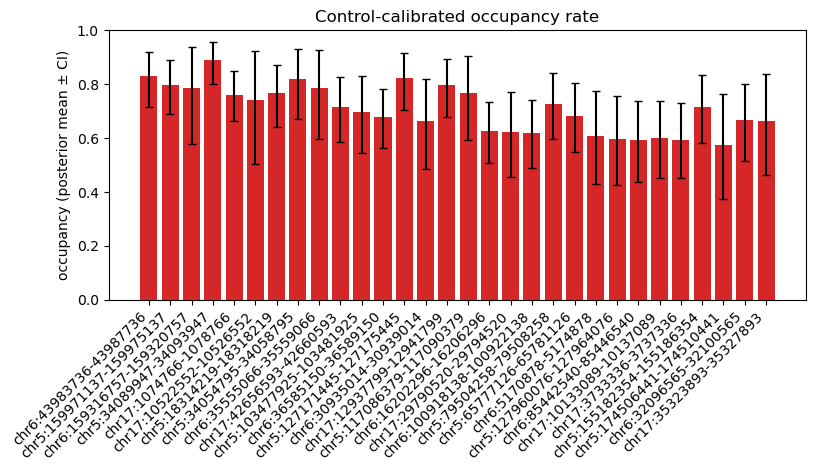

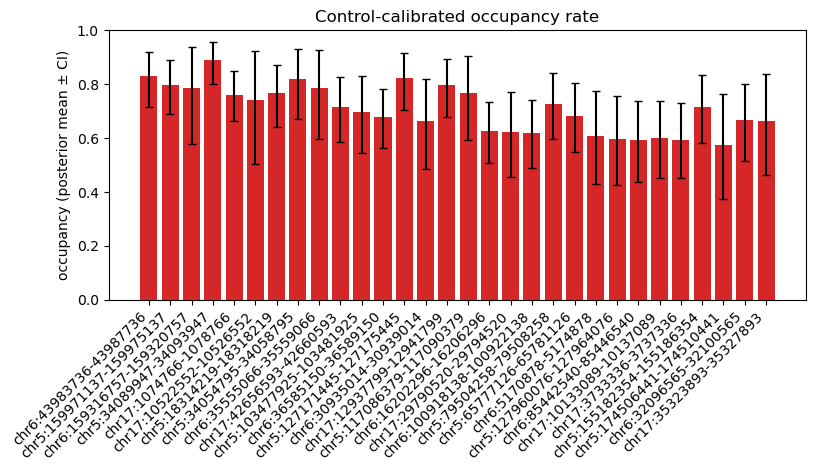

In [6]:
top_sites = site_occupancy.sort_values("occupancy_rate", ascending=False).head(30)
track = plotting.prepare_occupancy_rate_track_data(site_occupancy=top_sites)
fig, _ = plotting_matplotlib.plot_occupancy_rate_track_matplotlib(track)
fig.set_size_inches(9, 3.5)
fig

## Section B — binding strength (Q6)

`background.binding_strength` turns the per-read calls into a per-site **binding-strength** table:
control-calibrated occupancy (bound / total) with a Bayesian Beta posterior mean + credible
interval, the excess over the control false-positive rate, a two-proportion test vs control with
BH correction, and a rank. Occupancy here is the *only* strength axis — single-molecule methylation
magnitude and footprint are deliberately kept out of it.

Note `occupancy` is the hard true-signal rate while `occupancy_posterior_mean` / CI come from the
Beta posterior (which shrinks small-n sites), so we show them together.

In [7]:
strength = background.binding_strength(
    evidence=evidence,
    target_conditions=["targeted"],
    control_conditions=["control"],
    fdr=0.05,
    min_control_reads=5,
)
print("sites ranked:", len(strength), "| significant (FDR 0.05):", int(strength["significant"].sum()))
strength.sort_values("rank").head(10)[
    ["region_id", "rank", "occupancy", "occupancy_posterior_mean",
     "occupancy_ci_low", "occupancy_ci_high", "occupancy_excess", "q_value", "significant"]
]

sites ranked: 1792 | significant (FDR 0.05): 49


,region_id,rank,occupancy,occupancy_posterior_mean,occupancy_ci_low,occupancy_ci_high,occupancy_excess,q_value,significant
0,chr6:43983736-43987736,1,0.800000,0.829458,0.715994,0.918543,0.800000,0.001432,True
1,chr5:159971137-159975137,2,0.766667,0.798207,0.689727,0.888203,0.766667,0.011333,True
2,chr5:34089947-34093947,3,0.724138,0.891114,0.800823,0.956484,0.724138,0.010702,True
3,chr17:1074766-1078766,4,0.717949,0.761042,0.661748,0.847829,0.717949,0.000656,True
4,chr17:10522552-10526552,5,0.714286,0.742416,0.502462,0.921604,0.714286,0.033373,True
5,chr5:18314219-18318219,6,0.680000,0.765830,0.641664,0.870279,0.680000,0.000243,True
6,chr5:34054795-34058795,7,0.677419,0.819333,0.671105,0.929984,0.677419,0.004932,True
7,chr6:35555066-35559066,8,0.666667,0.786408,0.597328,0.926501,0.666667,0.034801,True
8,chr17:42656593-42660593,9,0.653846,0.713987,0.586484,0.826201,0.653846,0.012101,True
9,chr6:36585150-36589150,10,0.617647,0.678384,0.564487,0.782486,0.617647,0.000656,True


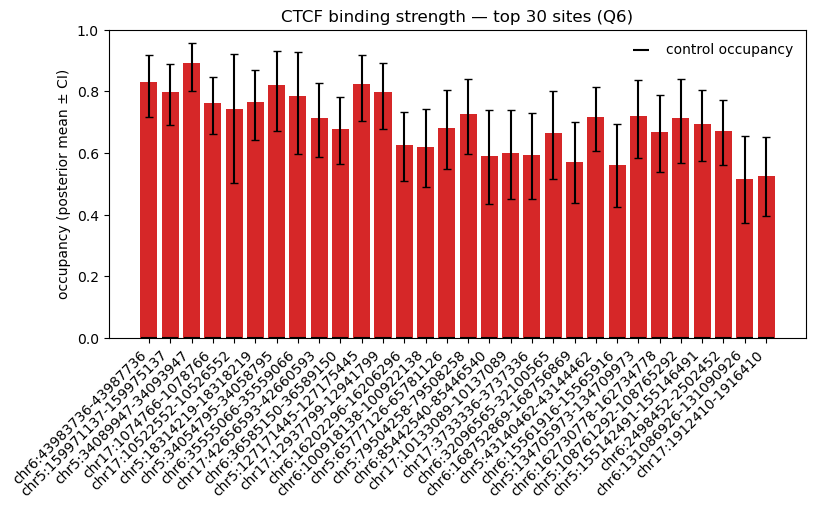

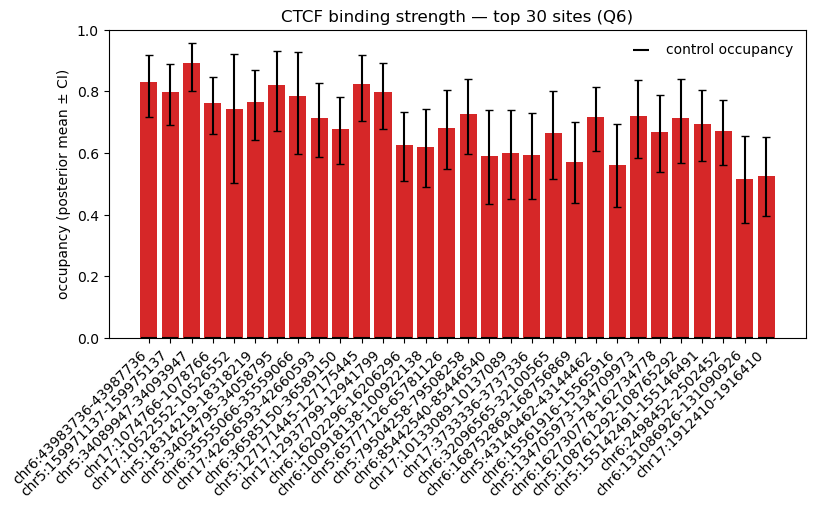

In [8]:
top30 = strength.sort_values("rank").head(30)
payload = plotting.prepare_binding_strength_data(binding_strength=top30)
fig, _ = plotting_matplotlib.plot_binding_strength_matplotlib(
    payload, title="CTCF binding strength — top 30 sites (Q6)"
)
fig.set_size_inches(9, 4)
fig

## Section C — single-molecule footprint (Q5)

A CTCF footprint is **dense methylation flanking a central protected (unmethylated) region** where
the bound factor occludes the DNA. Resolving it needs **base-precise motif centering**, so here we
re-window the *same* HDF5s on the exact JASPAR MA0139.1 motif matches (`clusters_ctcf.txt`),
±120 bp.

`footprint.aggregate_footprint_profile` gives the ensemble methylation profile; `call_footprints`
runs a 2-state Bernoulli HMM (backed by `hmmlearn`) per read to segment protected runs.

In [9]:
# motif-centered anchors from the JASPAR MA0139.1 matches
raw = pd.read_csv(OAK / "clusters_ctcf.txt", sep="\t", header=None)
motif_sites = (raw.iloc[:, [4, 5, 6, 9]]
               .set_axis(["chromosome", "start", "end", "strand"], axis=1)
               .drop_duplicates(subset=["chromosome", "start", "end"]))
motif_bed = OUT / "motif_anchors.bed"
motif_sites.assign(name=".", score=".")[
    ["chromosome", "start", "end", "name", "score", "strand"]
].to_csv(motif_bed, sep="\t", header=False, index=False)

WIN_MOTIF = 120  # -> 240 columns, motif center at index 120
res_motif = {
    sid: cluster.extract_read_windows(h5, motifs=["A,0"], regions=[str(motif_bed)],
                                      window_size=WIN_MOTIF)
    for sid, h5 in H5.items()
}
ANCHOR = res_motif["barcode17"].data_matrix.shape[1] // 2
print("motif anchors:", len(motif_sites),
      "| target windows:", res_motif["barcode17"].data_matrix.shape)

motif anchors: 1528 | target windows: (4320, 240)


### Ensemble footprint profile — target vs control
The targeted sample shows methylation peaks flanking a **protected dip at the motif center**; the untargeted control is flat and ~2–3× lower.

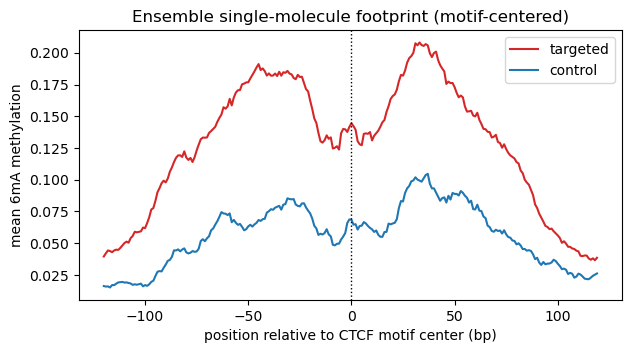

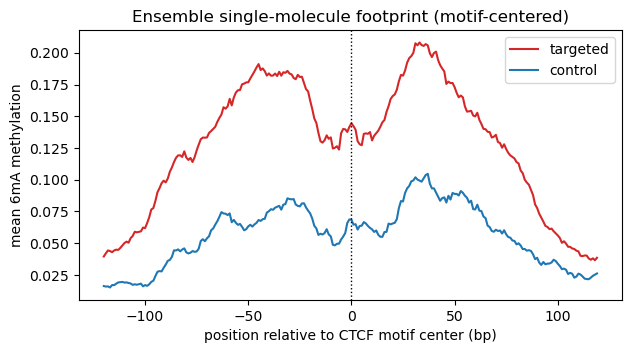

In [10]:
profiles = {}
for sid, r in res_motif.items():
    masked = np.where(r.val_matrix > 0, r.data_matrix, np.nan)
    profiles[sid] = footprint.aggregate_footprint_profile(masked)

fig, ax = plt.subplots(figsize=(7, 3.5))
rel = profiles["barcode17"]["position"].to_numpy() - ANCHOR
for sid, color, label in [("barcode17", "C3", "targeted"), ("barcode18", "C0", "control")]:
    m = profiles[sid]["mean_methylation"].to_numpy()
    sm = pd.Series(m).rolling(15, center=True, min_periods=5).mean()
    ax.plot(rel, sm, color=color, label=label)
ax.axvline(0, color="k", ls=":", lw=1)
ax.set_xlabel("position relative to CTCF motif center (bp)")
ax.set_ylabel("mean 6mA methylation")
ax.set_title("Ensemble single-molecule footprint (motif-centered)")
ax.legend()
fig

per-read footprints present: 132 / 1840 (7.2%)
HMM emission probs (protected, accessible): [0.013 0.499]
median protected width: 48 bp


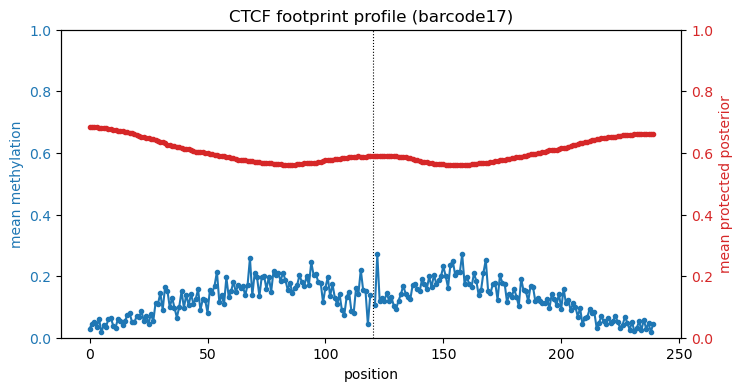

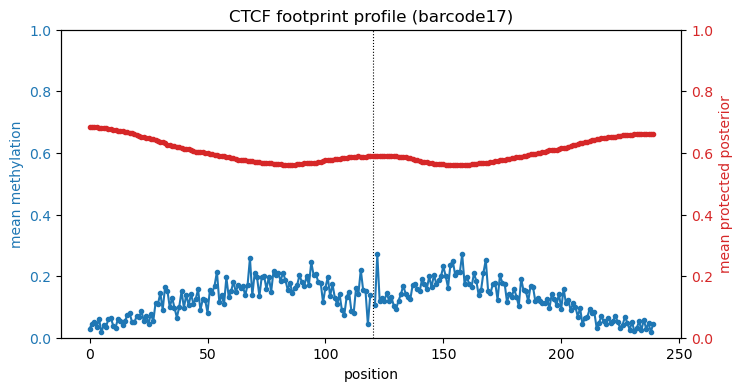

In [11]:
# per-read footprint calls on target reads with data near the anchor
rt = res_motif["barcode17"]
masked_t = np.where(rt.val_matrix > 0, rt.data_matrix, np.nan)
near = (rt.val_matrix[:, ANCHOR - 30:ANCHOR + 30] > 0).sum(axis=1) >= 4
fp_table, hmm = footprint.call_footprints(
    masked_t[near], anchor_index=ANCHOR, min_width=8, max_width=80
)
present = fp_table["footprint_present"]
print(f"per-read footprints present: {int(present.sum())} / {len(fp_table)} "
      f"({100 * present.mean():.1f}%)")
print(f"HMM emission probs (protected, accessible): {np.round(hmm.p_emit, 3)}")
print(f"median protected width: {fp_table.loc[present, 'protected_width'].median():.0f} bp")

prof_payload = plotting.prepare_footprint_profile_data(
    profile=profiles["barcode17"], anchor_index=ANCHOR
)
fig, _ = plotting_matplotlib.plot_footprint_profile_matplotlib(
    prof_payload, title="CTCF footprint profile (barcode17)"
)
fig

## Section D — motif validation against JASPAR (Q8)

Do our CTCF sites actually sit on the CTCF motif? `jaspar.fetch_jaspar_matrix` pulls the annotated
**MA0139.1** PWM; `motifs.extract_site_sequences` reads the chm13v2.0 sequence under each site;
`motifs.observed_pfm` / `information_content` build the observed logo; `compare_motifs` scores the
match.

observed sequences: 794 | total information: 17.4 bits
correlation to annotated MA0139.1: r = 0.995


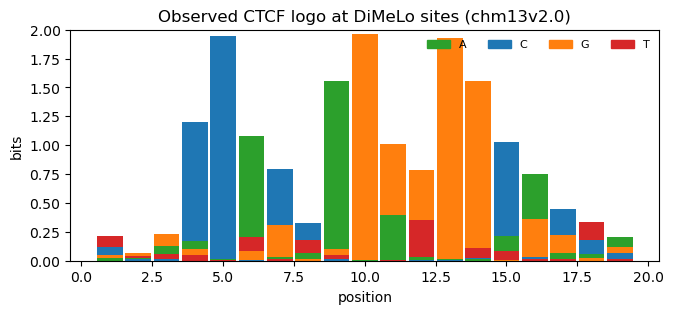

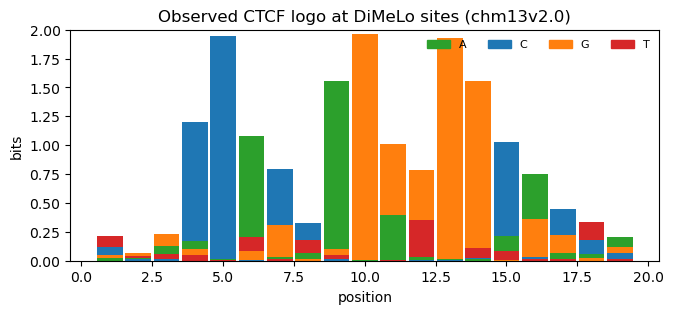

In [12]:
pwm = jaspar.fetch_jaspar_matrix("MA0139.1")

plus = motif_sites[motif_sites["strand"] == "+"].copy()
plus["center"] = ((plus["start"] + plus["end"]) // 2).astype(int)
seqs = motifs.extract_site_sequences(REF, plus.head(1000), width=19)

obs_prob = motifs.counts_to_probability(motifs.observed_pfm(seqs))
ic = motifs.information_content(obs_prob)
comparison = motifs.compare_motifs(obs_prob, motifs.counts_to_probability(pwm))
print(f"observed sequences: {len(seqs)} | total information: {ic['bits'].sum():.1f} bits")
print(f"correlation to annotated MA0139.1: r = {comparison['pearson_r']:.3f}")

logo = plotting.prepare_sequence_logo_data(information_content=ic)
fig, _ = plotting_matplotlib.plot_sequence_logo_matplotlib(
    logo, title="Observed CTCF logo at DiMeLo sites (chm13v2.0)"
)
fig

## Section E — what is each read-cluster associated with? (Q8)

The reads were clustered by methylation pattern into 5 groups (`cluster_0..4.bed`). Which of them
correspond to genuine CTCF binding? `cluster_reference.annotate_clusters_by_site_groups` computes,
per cluster, the fraction of sites overlapping an **ENCODE CTCF ChIP-seq peak set** and a Fisher
enrichment vs the other clusters.

In [13]:
clusters = pd.concat([
    pd.read_csv(OAK / f"cluster_{i}.bed", sep="\t", header=None).iloc[:, :3]
      .set_axis(["chromosome", "start", "end"], axis=1)
      .assign(cluster=f"cluster_{i}")
    for i in range(5)
], ignore_index=True)

encode_ctcf = encode.load_encode_peaks(OAK / "ENCFF748UZH.chm13.bed", max_peaks=400000)
association = cluster_reference.annotate_clusters_by_site_groups(
    clusters, {"encode_ctcf": encode_ctcf}
)
association

,group,cluster,n_sites,n_feature,feature_fraction,odds_ratio,p_value,q_value,significant
0,encode_ctcf,cluster_0,5671,5512,0.971963,1.515324,8.067206e-08,1.008401e-07,True
1,encode_ctcf,cluster_1,6375,6248,0.980078,2.211522,3.161935e-22,1.580968e-21,True
2,encode_ctcf,cluster_2,4075,3978,0.976196,1.788773,1.081978e-09,2.704944e-09,True
3,encode_ctcf,cluster_3,16778,16214,0.966385,1.299880,2.467568e-08,4.112613e-08,True
4,encode_ctcf,cluster_4,27499,25995,0.945307,0.512264,1.000000e+00,1.000000e+00,False


## Summary

On full-depth real CTCF DiMeLo-seq data, the single-molecule stack delivers what the ensemble
pileup cannot:

- **A/B** — a negative control turns raw per-read methylation into **calibrated true-signal calls**
  and a ranked, **significance-tested binding-strength** table.
- **C** — motif-centered footprinting recovers the classic **protected-center / methylated-flank**
  CTCF signature at single-molecule resolution.
- **D/E** — native **JASPAR** and **ENCODE** connectors validate that the sites carry the CTCF motif
  and that specific read-clusters are enriched for CTCF ChIP peaks.

The same functions run on the small committed demo subset (at lower depth / weaker signal) for CI
and quick experimentation.